# NAND THAKOR_TASK 3

# Car Price Prediction With Machine Learning

### Importing Libraries

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

### Loading Dataset

In [69]:
df=pd.read_csv("car data.csv")

### Understanding Dataset

In [70]:
df.shape

(301, 9)

In [71]:
df.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [72]:
df.sample(5)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
161,TVS Apache RTR 180,2014,0.45,0.826,23000,Petrol,Individual,Manual,0
233,grand i10,2013,3.90,5.700,53000,Diesel,Dealer,Manual,0
80,corolla altis,2016,14.73,14.890,23000,Diesel,Dealer,Manual,0
238,verna,2013,4.80,9.400,60241,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.150,5200,Petrol,Dealer,Manual,0


In [73]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


### Data Cleaning and Preprocessing

##### Checking Missing Values

In [75]:
df.isnull().count()

Car_Name         301
Year             301
Selling_Price    301
Present_Price    301
Driven_kms       301
Fuel_Type        301
Selling_type     301
Transmission     301
Owner            301
dtype: int64

In [76]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [77]:
df.columns = df.columns.str.strip()

## Exploratory Data Analysis 

#### Correlation Heatmap

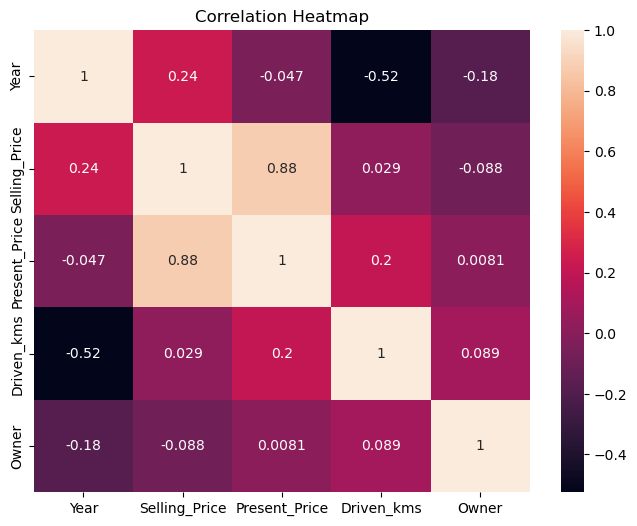

In [78]:
numeric_df=df.select_dtypes(include="number")
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(),annot=True)
plt.title("Correlation Heatmap")
plt.show()

#### Selling Price Distribution

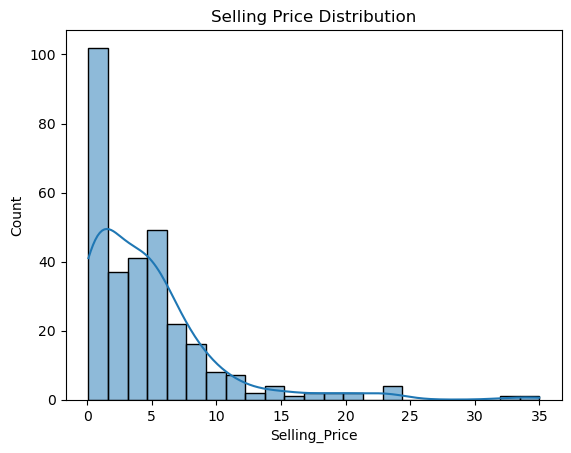

In [79]:
sns.histplot(df["Selling_Price"],kde=True)
plt.title("Selling Price Distribution")
plt.show()

#### Relationship Between Present Price and Selling Price 

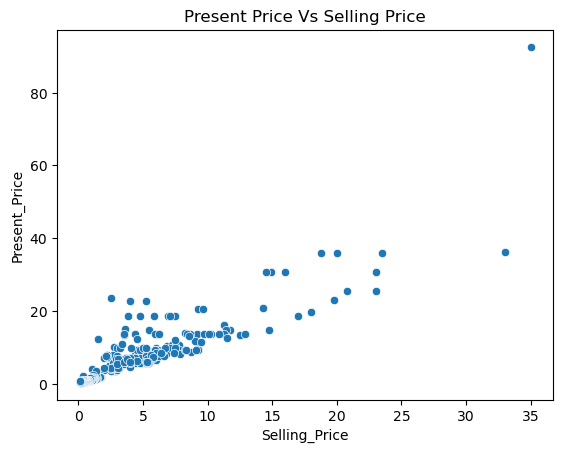

In [80]:
sns.scatterplot(x=df["Selling_Price"],y=df["Present_Price"])
plt.title("Present Price Vs Selling Price")
plt.show()

#### Feature Engineering

In [81]:
df["car_age"]=2026-df["Year"]

In [82]:
df.drop("Year",axis=1,inplace=True)
df.drop("Car_Name",axis=1,inplace=True)

### Encoding Categorical Data

In [83]:
print(df["Fuel_Type"].unique())
print(df["Transmission"].unique())
print(df["Selling_type"].unique())

['Petrol' 'Diesel' 'CNG']
['Manual' 'Automatic']
['Dealer' 'Individual']


In [84]:
df=pd.get_dummies(df,drop_first=True)

In [85]:
df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,car_age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


#### Prepare Features and Target

In [86]:
X=df.drop("Selling_Price",axis=1)
y=df["Selling_Price"]

#### Splitting Dataset into Training and Testing data set 

In [87]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#### Model Training 

In [88]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [89]:
Pred=model.predict(X_test)

#### Model Evaluation

In [90]:
from sklearn.metrics import mean_absolute_error,r2_score
mae=mean_absolute_error(y_test,Pred)
r2=r2_score(y_test,Pred)
print("Mean Absolute Error",mae)
print("R2 score:",r2)

Mean Absolute Error 1.2163740193330355
R2 score: 0.8488707839193155


#### Visualize Predictions 

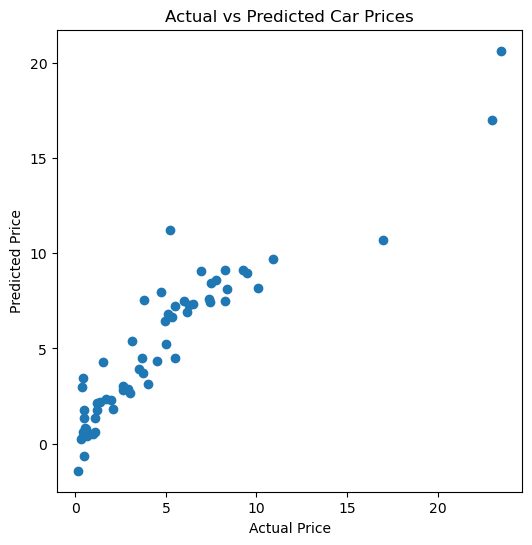

In [91]:
plt.figure(figsize=(6,6))
plt.scatter(y_test,Pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

#### Save Model 

In [92]:
import joblib 
joblib.dump(model,"Car_Price_Model.pkl")


['Car_Price_Model.pkl']

In [93]:
X.columns

Index(['Present_Price', 'Driven_kms', 'Owner', 'car_age', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual'],
      dtype='object')

In [94]:
loaded_model = joblib.load("Car_Price_Model.pkl")
sample_data=pd.DataFrame([[6.45,27000,0,10,0,1,0,1]],columns=X.columns)
prediction=loaded_model.predict(sample_data)
print("Predicted car Price:",prediction)

Predicted car Price: [5.01029319]


## Conclusion

#### This project focused on predicting car selling prices using machine learning techniques.
##### The dataset was cleaned and preprocessed by handling categorical variables and creating useful features such as car age. Exploratory Data Analysis (EDA) helped in understanding the relationships between different features and the selling price.
##### A Linear Regression model was trained to predict car prices based on factors such as present price, kilometers driven, fuel type, transmission type, and car age.